In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

In [5]:
df = pd.read_csv("/home/manoj/Desktop/Work/6th Sem/DSBDA/Social_Network_Ads.xls")

In [6]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [7]:
X = df.iloc[:, [2, 3]].values
y = df.iloc[:, 4].values
print(X[:3, :])
print('-'*15)
print(y[:3])

[[   19 19000]
 [   35 20000]
 [   26 43000]]
---------------
[0 0 0]


In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

print(X_train[:3])
print('-'*15)
print(y_train[:3])
print('-'*15)
print(X_test[:3])
print('-'*15)
print(y_test[:3])

[[    39 106000]
 [    39  71000]
 [    32 117000]]
---------------
[1 0 1]
---------------
[[   26 15000]
 [   30 80000]
 [   35 55000]]
---------------
[0 0 0]


In [9]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

print(X_train[:3])
print('-'*15)
print(X_test[:3])

[[ 0.16680455  1.06709028]
 [ 0.16680455  0.02287332]
 [-0.50296516  1.39527275]]
---------------
[[-1.07705349 -1.6478738 ]
 [-0.69432794  0.29138626]
 [-0.215921   -0.454483  ]]


In [10]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0, solver='lbfgs')
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

print(X_test[:10])
print('-'*15)
print(y_pred[:10])

[[-1.07705349 -1.6478738 ]
 [-0.69432794  0.29138626]
 [-0.215921   -0.454483  ]
 [ 2.0804323   2.17097677]
 [-1.45977904 -1.55836949]
 [ 0.26248594 -0.33514392]
 [ 1.50634398  1.00742074]
 [ 0.26248594  2.141142  ]
 [ 0.45384872  0.58973396]
 [-0.69432794  1.93229861]]
---------------
[0 0 0 1 0 0 1 1 1 0]


In [11]:
print(y_pred[:20])
print(y_test[:20])

[0 0 0 1 0 0 1 1 1 0 0 0 0 1 1 0 0 1 1 0]
[0 0 0 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1]


In [17]:
matrix = confusion_matrix(y_test,y_pred,labels = classifier.classes_)
print(matrix)

tp, fn, fp, tn = confusion_matrix(y_test,y_pred,labels=[1,0]).reshape(-1)


print(classification_report(y_test,y_pred))

print('True Positives:',tp)
print('False Negatives:',fn)
print('False Positives:',fp)
print('True Negatives:',tn)

print('Accuracy:',accuracy_score(y_test,y_pred))
print('Error Rate:',1-accuracy_score(y_test,y_pred))
print('Precision:',precision_score(y_test,y_pred))
print('Recall:',recall_score(y_test,y_pred))



     


[[55  7]
 [ 9 29]]
              precision    recall  f1-score   support

           0       0.86      0.89      0.87        62
           1       0.81      0.76      0.78        38

    accuracy                           0.84       100
   macro avg       0.83      0.83      0.83       100
weighted avg       0.84      0.84      0.84       100

True Positives: 29
False Negatives: 9
False Positives: 7
True Negatives: 55
Accuracy: 0.84
Error Rate: 0.16000000000000003
Precision: 0.8055555555555556
Recall: 0.7631578947368421


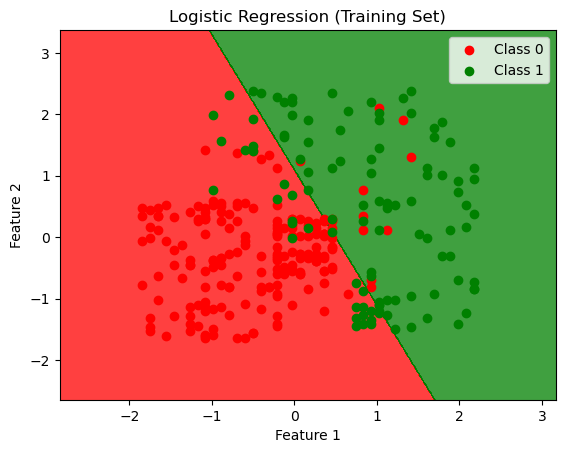

In [16]:
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt

X_set, y_set = X_train, y_train


X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)


Z = classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape)

# boundary draw
plt.contourf(X1, X2, Z, alpha=0.75, cmap=ListedColormap(['red', 'green']))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# actual points
colors = ['red', 'green']
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0],
                X_set[y_set == j, 1],
                c=colors[i], label=f'Class {j}')

plt.title('Logistic Regression (Training Set)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


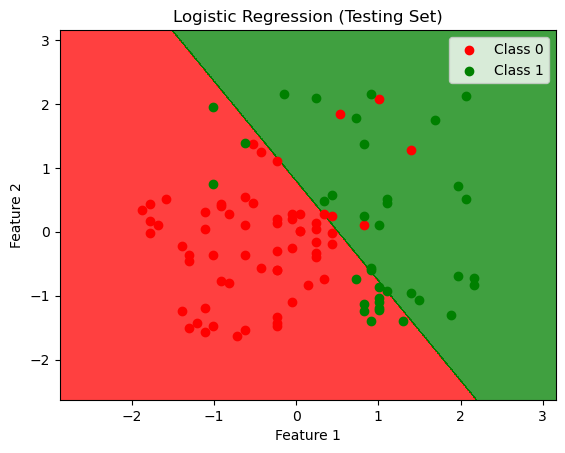

In [26]:
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt

X_set, y_set = X_test, y_test


X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)


Z = classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape)

# decision boundary
plt.contourf(X1, X2, Z, alpha=0.75, cmap=ListedColormap(['red', 'green']))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# actual data points
colors = ['red', 'green']
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0],
                X_set[y_set == j, 1],
                c=colors[i], label=f'Class {j}')

plt.title('Logistic Regression (Testing Set)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()
